# Welltory Data Exploration

## 1. Data background
This dataset comes from Welltory's 2020 COVID-19 research project. Participating app users provided heart-rate variability (HRV) measurements and personal information. Measurements could come from a phone camera or a heart-rate monitor.


I use two files to keep this exploration focused:
- `participants.csv`: one row per participant.
- `hrv_measurements.csv`: one row per HRV measurement. A participant can have many measurements.


## 2. Import Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

participants = pd.read_csv("../data/participants.csv")
hrv = pd.read_csv("../data/hrv_measurements.csv")

print("Participants table:", participants.shape)
print("HRV table:", hrv.shape)

Participants table: (185, 8)
HRV table: (3245, 22)


## 3. Understand the columns
I focus on the following columns in this analysis:

user_code: Participant ID used to identify the same person across tables.

height: Height in centimeters.

weight: Weight in kilograms.

age_range: Age group, not exact age.

country: Recorded country.

symptoms_onset: Reported date when symptoms started.

rr_code: Unique HRV measurement ID.

measurement_datetime: Date and time of the measurement.

bpm: Heart rate in beats per minute.

rmssd: A measure of variation between successive heartbeat intervals, in milliseconds.

sdnn: Standard deviation of normal heartbeat intervals, in milliseconds.

how_sleep: Self-reported sleep score. A missing value is different from a score of zero.

I focus on these columns rather than trying to analyze every available variable.

In [3]:
display(participants.head())
display(hrv[["user_code", "measurement_datetime", "bpm", "rmssd", "sdnn", "how_sleep"]].head())
participants.info()
hrv.info()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


,user_code,measurement_datetime,bpm,rmssd,sdnn,how_sleep
0,007b8190cf,2020-04-21 21:23:08,75,54.174,45.802,NaN
1,007b8190cf,2020-04-26 11:19:25,70,33.022,32.889,0.0
2,013f6d3e5b,2020-05-15 04:14:21,83,65.987,54.811,NaN
3,013f6d3e5b,2020-05-19 03:06:02,75,70.039,72.223,NaN
4,01bad5a519,2019-12-31 09:07:43,78,21.196,29.650,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245

In [4]:
display(participants[["height", "weight"]].describe())
display(hrv[["bpm", "rmssd", "sdnn"]].describe())

records_per_person = hrv.groupby("user_code").size()
display(records_per_person.describe())

,height,weight
count,183.000000,185.000000
mean,169.976393,77.927757
std,12.400103,19.552541
min,132.080000,43.500000
25%,163.500000,63.500000
50%,168.000000,74.344000
75%,174.500000,90.537000
max,250.000000,154.221000


,bpm,rmssd,sdnn
count,3245.000000,3245.000000,3245.000000
mean,73.257935,52.814196,52.489218
std,12.201088,39.353213,29.369506
min,44.000000,6.340000,9.515000
25%,65.000000,28.985000,32.585000
50%,72.000000,42.869000,46.919000
75%,81.000000,62.485000,64.406000
max,125.000000,310.800000,206.631000


count    185.000000
mean      17.540541
std       45.790517
min        1.000000
25%        1.000000
50%        4.000000
75%       12.000000
max      405.000000
dtype: float64

### What I found
There are 185 participants and 3245 HRV measurements.
The median participant has 4 measurements, but one participant has 405. So, 3245 measurements do not mean 3245 independent people.

## 4. Missing values
First, I count missing values. I keep missing numerical measurements rather than filling them with an average, because an invented value could distort the distribution.

For country, I use an **Unknown** category in the analysis copy. Missing height remains missing. A missing sleep score is not replaced with zero because zero is already an observed score.

In [5]:
display(participants.isna().sum().to_frame("missing_count"))
display(hrv.isna().sum().to_frame("missing_count"))

# Work on copies so the original data stays unchanged.
participants_clean = participants.copy()
hrv_clean = hrv.copy()

participants_clean["country"] = participants_clean["country"].fillna("Unknown")
hrv_clean["sleep_score_missing"] = hrv_clean["how_sleep"].isna()

print("Missing height:", participants_clean["height"].isna().sum())
print("Missing sleep score:", hrv_clean["how_sleep"].isna().sum())

,missing_count
user_code,0
gender,0
age_range,0
city,12
country,6
height,2
weight,0
symptoms_onset,38


,missing_count
user_code,0
rr_code,0
measurement_datetime,0
time_of_day,0
bpm,0
meanrr,0
mxdmn,0
sdnn,0
rmssd,0
pnn50,0


Missing height: 2
Missing sleep score: 1779


Height is missing for 2 participants. The sleep score is missing for 1779 measurements, about 54.8% of the HRV table. This limits sleep-related analysis, so I focus on the complete heart-rate and HRV measurements.

## 5. Duplicates and data integrity
I remove only exact duplicate rows. I also check that participant IDs and measurement IDs are unique in their respective tables and that every HRV participant appears in the participant table.

In [6]:
print("Duplicate participant rows:", participants_clean.duplicated().sum())
print("Duplicate HRV rows:", hrv_clean.duplicated().sum())

participants_clean = participants_clean.drop_duplicates()
hrv_clean = hrv_clean.drop_duplicates()

print("Participant IDs are unique:", participants_clean["user_code"].is_unique)
print("Measurement IDs are unique:", hrv_clean["rr_code"].is_unique)
print("Missing participant IDs:", participants_clean["user_code"].isna().sum())
print("Missing HRV participant IDs:", hrv_clean["user_code"].isna().sum())
print("HRV rows with an unknown participant:",
      (~hrv_clean["user_code"].isin(participants_clean["user_code"])).sum())

Duplicate participant rows: 0
Duplicate HRV rows: 0
Participant IDs are unique: True
Measurement IDs are unique: True
Missing participant IDs: 0
Missing HRV participant IDs: 0
HRV rows with an unknown participant: 0


No exact duplicates are present, so this step removes no rows.

## 6. Outliers and visual exploration
I use a boxplot to look for unusual RMSSD values. Points beyond the whiskers are potential outliers.

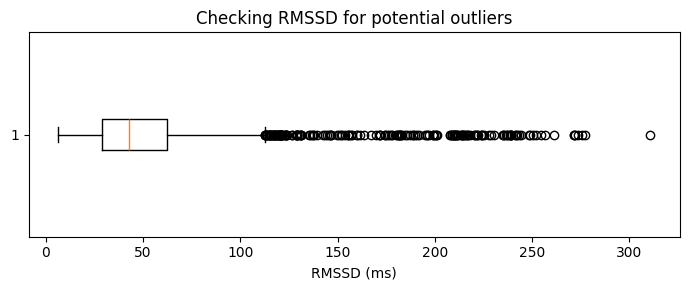

In [7]:
plt.figure(figsize=(7, 3))
plt.boxplot(hrv_clean["rmssd"].dropna(), vert=False)
plt.title("Checking RMSSD for potential outliers")
plt.xlabel("RMSSD (ms)")
plt.tight_layout()
plt.show()

The boxplot shows several potential outliers on the high end of RMSSD. I retain these observations because the plot alone does not establish that they are incorrect.

## 7. Data transformation
I convert **measurement_datetime** from text to a datetime type so that dates can be used for time calculations and grouping. Values that cannot be converted become missing, and I count them to check the conversion.

In [8]:
hrv_clean["measurement_datetime"] = pd.to_datetime(
    hrv_clean["measurement_datetime"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

print("Date column type:", hrv_clean["measurement_datetime"].dtype)

print("Missing or invalid dates:",
    hrv_clean["measurement_datetime"].isna().sum())

Date column type: datetime64[ns]
Missing or invalid dates: 0


The measurement dates were successfully converted to datetime format. No missing or invalid measurement dates were found.

## 8. Create a new feature: BMI
**New feature:** Body mass index (BMI).

**Formula:** `BMI = weight in kilograms / (height in meters)^2`

Height is recorded in centimeters, so I divide it by 100 before calculating BMI. This combines two existing columns into a simple body-size measure.

In [9]:
valid_size = (participants_clean["height"] > 0) & (participants_clean["weight"] > 0)

participants_clean["height_m"] = participants_clean["height"] / 100
participants_clean["bmi"] = (
    participants_clean["weight"] / participants_clean["height_m"] ** 2
).where(valid_size)

display(participants_clean[["user_code", "height", "weight", "bmi"]].head())
display(participants_clean["bmi"].describe())
print("Participants without a calculated BMI:", participants_clean["bmi"].isna().sum())

,user_code,height,weight,bmi
0,007b8190cf,170.18,96.162,33.203698
1,013f6d3e5b,174.00,77.300,25.531774
2,01bad5a519,178.00,92.000,29.036738
3,0210b20eea,169.00,60.000,21.007668
4,024719e7da,158.00,68.500,27.439513


count    183.000000
mean      27.158034
std        7.174349
min       13.143360
25%       22.303275
50%       26.244852
75%       30.363220
max       54.277185
Name: bmi, dtype: float64

Participants without a calculated BMI: 2


BMI can be calculated for 183 of 185 participants. The two missing heights lead to two missing BMI values.

## 9. Relationship between heart rate and RMSSD
To give each person one point, I calculate their median heart rate and median RMSSD. I then make a scatter plot.

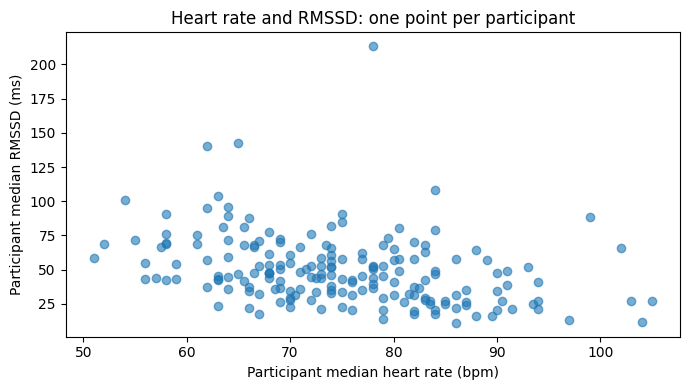

Number of participants: 185


In [10]:
person_medians = hrv_clean.groupby("user_code")[["bpm", "rmssd"]].median()

plt.figure(figsize=(7, 4))
plt.scatter(person_medians["bpm"], person_medians["rmssd"], alpha=0.6)
plt.title("Heart rate and RMSSD: one point per participant")
plt.xlabel("Participant median heart rate (bpm)")
plt.ylabel("Participant median RMSSD (ms)")
plt.tight_layout()
plt.show()

print("Number of participants:", len(person_medians))

The scatter plot suggests a general downward pattern: participants with higher median heart rates tend to have lower median RMSSD, although there is considerable variation. This association does not establish causation or show that COVID-19 caused the pattern.

## 10. Data quality and conclusion

I checked the table sizes, column types, and summary statistics to understand the data. Some height values and sleep scores were missing, so I kept these numerical values missing rather than guessing replacements. I found no exact duplicates, and all HRV participant IDs matched the participant table. I converted measurement dates to datetime format and height to meters before calculating BMI. Some values like a height of 250 cm and unusually high RMSSD measurements need further checking. I cannot confirm their accuracy from these files alone.